In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\coffee_shop.csv")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [27]:
# Data Cleaning
df['datetime'] = pd.to_datetime(df['transaction_date']+' '+df['transaction_time'],format="%d-%m-%Y %H:%M:%S")


missing_values = df.isnull().sum()
duplicate_values = df.duplicated().sum()


In [28]:
# Feature Engineering
df['hour'] = df['datetime'].dt.hour
df['date'] = df['datetime'].dt.date
df['weekday_name'] = df['datetime'].dt.day_name()
df['weekday_period'] = df['datetime'].dt.to_period('W')
df['month'] = df['datetime'].dt.to_period("M")
df['is_holyday'] = np.where(df['weekday_name'].str.contains('Saturday','Sunday'),1,0)

df['revenue'] = df['transaction_qty'] * df['unit_price']


In [29]:
# Business Question
total_revenue = df['revenue'].sum()
best_store_by_revenue = df.groupby('store_location')['revenue'].sum().idxmax()
best_store_by_customer_foot = df.groupby('store_location')['transaction_id'].nunique().idxmax()
peak_hour_across_stores = df.pivot_table(index='hour',columns=['store_location'],values=['transaction_id'],aggfunc='nunique',fill_value=0).idxmax()


best_selling_product_by_revenue = df.groupby('product_type')['revenue'].sum().sort_values(ascending=False).head(1)
best_selling_product_by_quantity = df.groupby('product_type')['transaction_qty'].sum().sort_values(ascending=False).head(1)
highest_revenue_category = df.groupby('product_category')['revenue'].sum().idxmax()
slow_moving_items = df.pivot_table(index='product_type',values='transaction_qty',aggfunc='sum').sort_values(by='transaction_qty').head(10)


busiest_weekday = df.pivot_table(index='weekday_name',values='transaction_id',aggfunc='nunique').idxmax()
hourly_demand = df.pivot_table(index='hour',columns='product_category',values='transaction_id',aggfunc='nunique')
"""sns.heatmap(hourly_demand)"""
seasonal_demand = df.groupby('month')['product_category'].value_counts().groupby(level=0).head(5)


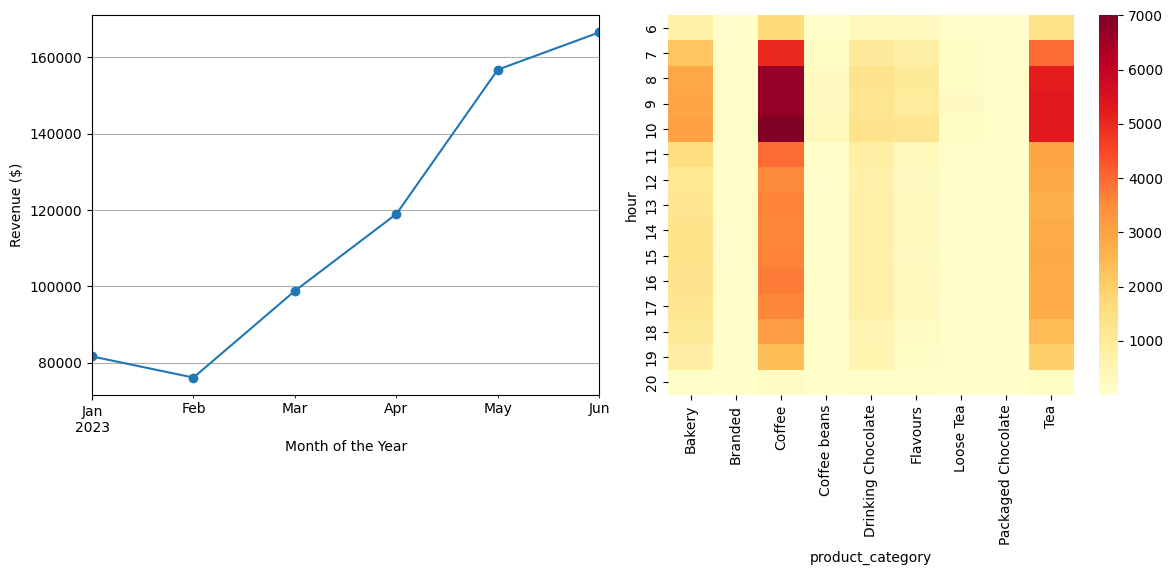

In [30]:
# Visualization Section
fig,axes = plt.subplots(1,2,figsize=(24,8))

monthly_revenue_trend = df.groupby('month')['revenue'].sum().plot(kind='line',ax=axes[0],xlabel='Month of the Year',
                                     ylabel='Revenue ($)',
                                     marker='o',figsize=(12,6),grid=True) 


buying_trend = df.groupby('hour')['product_category'].value_counts().unstack(fill_value=0)
sns.heatmap(buying_trend,ax=axes[1],cmap='YlOrRd')
plt.suptitle('')
plt.xticks(rotation=90)
plt.tight_layout()

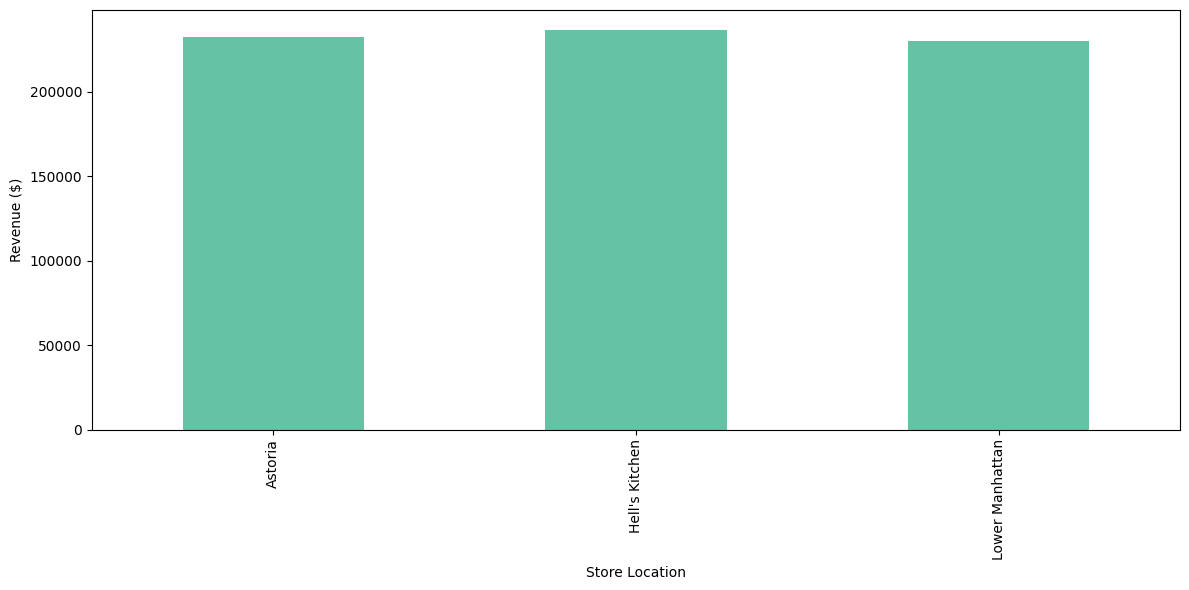

In [31]:
store_wise_revenue = df.groupby('store_location')['revenue'].sum().plot(kind='bar',
                                colormap='Set2',
                                figsize=(12,6),xlabel='Store Location',
                                ylabel='Revenue ($)')
plt.tight_layout()

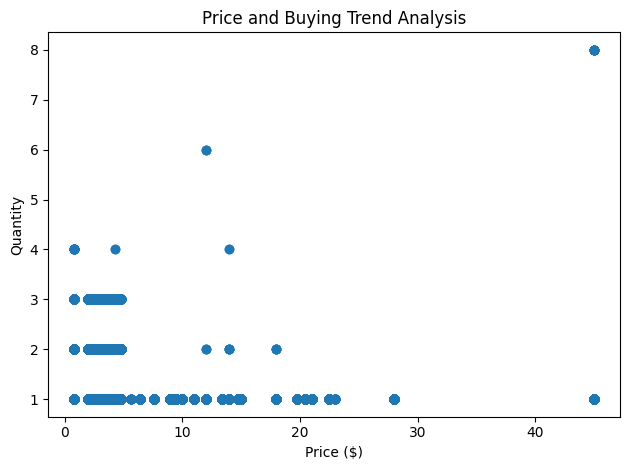

In [32]:
# Visualization Section Continued..
price_and_quantity_relation = plt.scatter(df['unit_price'],df['transaction_qty'])
plt.title('Price and Buying Trend Analysis')
plt.xlabel('Price ($)')
plt.ylabel('Quantity')

plt.tight_layout()

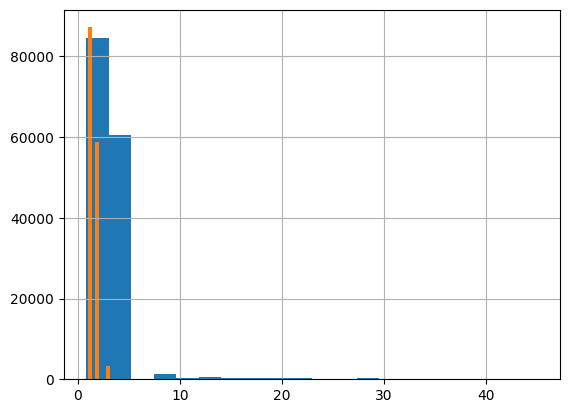

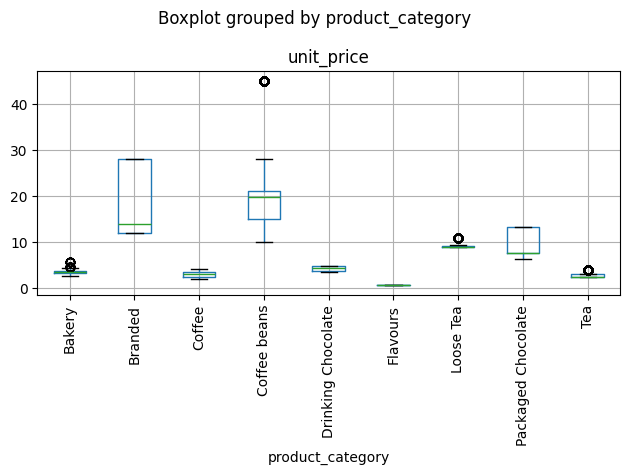

In [33]:
# Visualization Section Continued..

price_dist,quantity_dis = df['unit_price'].hist(bins=20),df['transaction_qty'].hist(bins=20)
price_detailed = df.boxplot(by='product_category',column='unit_price',rot=90)
plt.tight_layout()

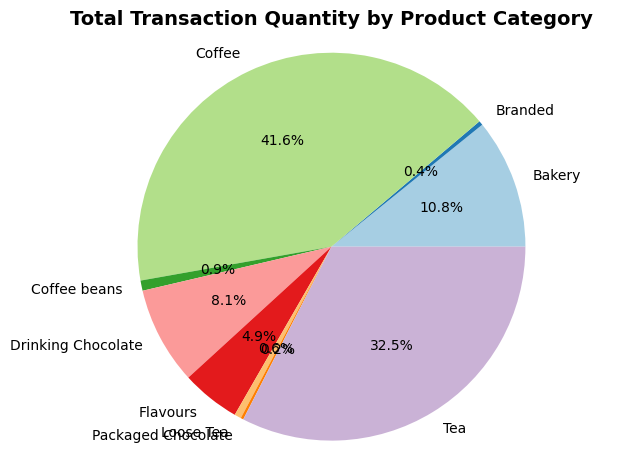

In [34]:
gb = df.groupby('product_category')['revenue'].sum()#.plot(kind='pie',autopct="%1.01f%%")
total_quantity = df.pivot_table(index='product_category',values='transaction_qty',aggfunc='sum')
plt.pie(total_quantity['transaction_qty'],autopct='%1.1f%%',labels=total_quantity.index,
        colors=plt.cm.Paired.colors )


plt.title('Total Transaction Quantity by Product Category', fontsize=14, weight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()